#Первичный анализ данных

In [98]:
#скачал txt-файл и выложил к себе на диск,
#тк через od.download опять не получалось, как и в ДЗ №3

!gdown 1dr61qQnnVmtLC7dNlX5KOUJKVPnCS2R1

Downloading...
From: https://drive.google.com/uc?id=1dr61qQnnVmtLC7dNlX5KOUJKVPnCS2R1
To: /content/Run200_Wave_0_1.txt
100% 71.3M/71.3M [00:00<00:00, 96.1MB/s]


In [99]:
#загружаем библиотеки, которые понадобятся в будущем

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
import umap
from sklearn.mixture import GaussianMixture

#библиотеки прошлых попыток
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [100]:
#обеспечиваем воспроизводимость

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [101]:
#прекод из Каггла
#удаляются 1, 2, 3, 4 и 505 столбцы

X = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
X = X.drop([0, 1, 2, 3, 504], axis=1)
X.columns = list(range(500))
X.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [102]:
X.shape

(23479, 500)

###Датасет не слишком большой, пока в планах использовать K-Means (но это под большим вопросом, конечно, всё-таки 500 признаков) и Isolation Forest.

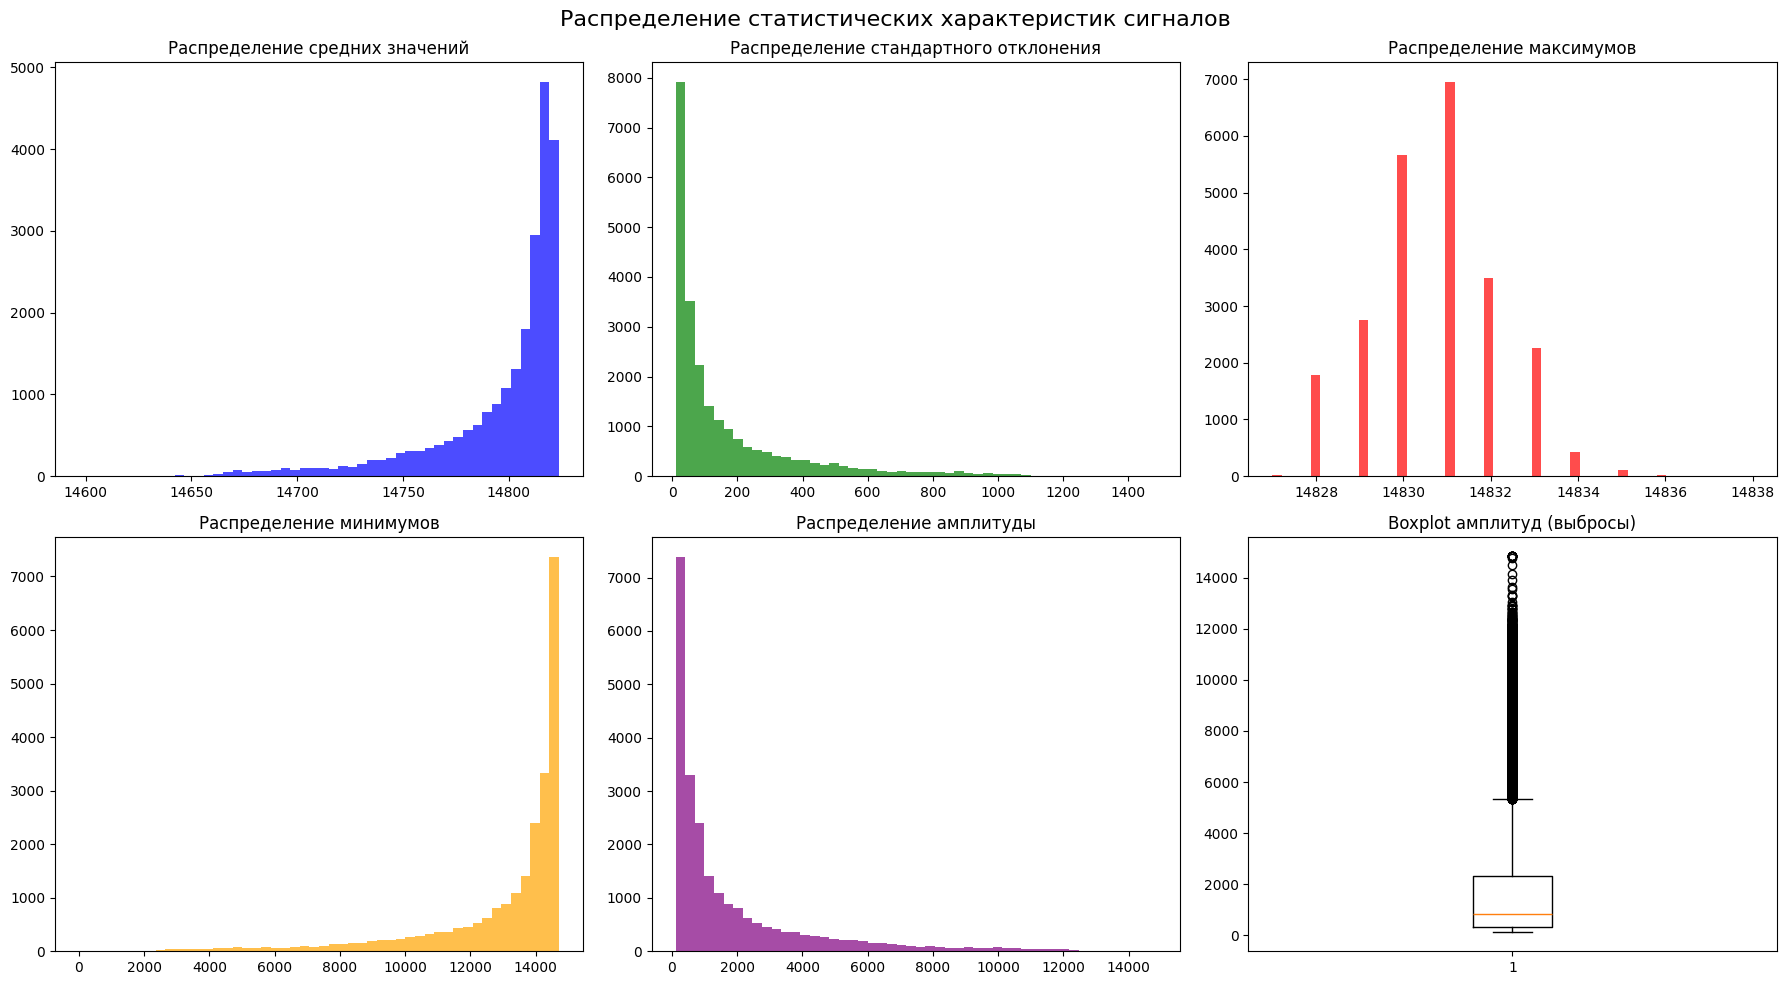

In [103]:
#посмотрим распределение ключевых характеристик

X_stats = pd.DataFrame()
X_stats['mean'] = X.mean(axis=1)
X_stats['std'] = X.std(axis=1)
X_stats['max'] = X.max(axis=1)
X_stats['min'] = X.min(axis=1)
X_stats['amplitude'] = X_stats['max'] - X_stats['min']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Распределение статистических характеристик сигналов', fontsize=16)

axes[0, 0].hist(X_stats['mean'], bins=50, color='blue', alpha=0.7)
axes[0, 0].set_title('Распределение средних значений')

axes[0, 1].hist(X_stats['std'], bins=50, color='green', alpha=0.7)
axes[0, 1].set_title('Распределение стандартного отклонения')

axes[0, 2].hist(X_stats['max'], bins=50, color='red', alpha=0.7)
axes[0, 2].set_title('Распределение максимумов')

axes[1, 0].hist(X_stats['min'], bins=50, color='orange', alpha=0.7)
axes[1, 0].set_title('Распределение минимумов')

axes[1, 1].hist(X_stats['amplitude'], bins=50, color='purple', alpha=0.7)
axes[1, 1].set_title('Распределение амплитуды')

# Свободный график можно использовать подbox-plot амплитуд для поиска явных выбросов
axes[1, 2].boxplot(X_stats['amplitude'])
axes[1, 2].set_title('Boxplot амплитуд (выбросы)')

plt.tight_layout()
plt.show()

###Проанализировав графики можно сделать, на мой взгляд, главный и очевидный вывод: четкого распределения на кластеры не будет. Это связано с отсутствием четких переходов в графиках. Максимальный значения довольно плавно перетекают в хвост.
###Также, сразу видно то, что выбросов будет довольно прилично.
###Пространство признаков нужно будет сжимать, либо выделять другие фичи (амплитуду, площадь и прочее).

Text(0, 0.5, 'bit ADC')

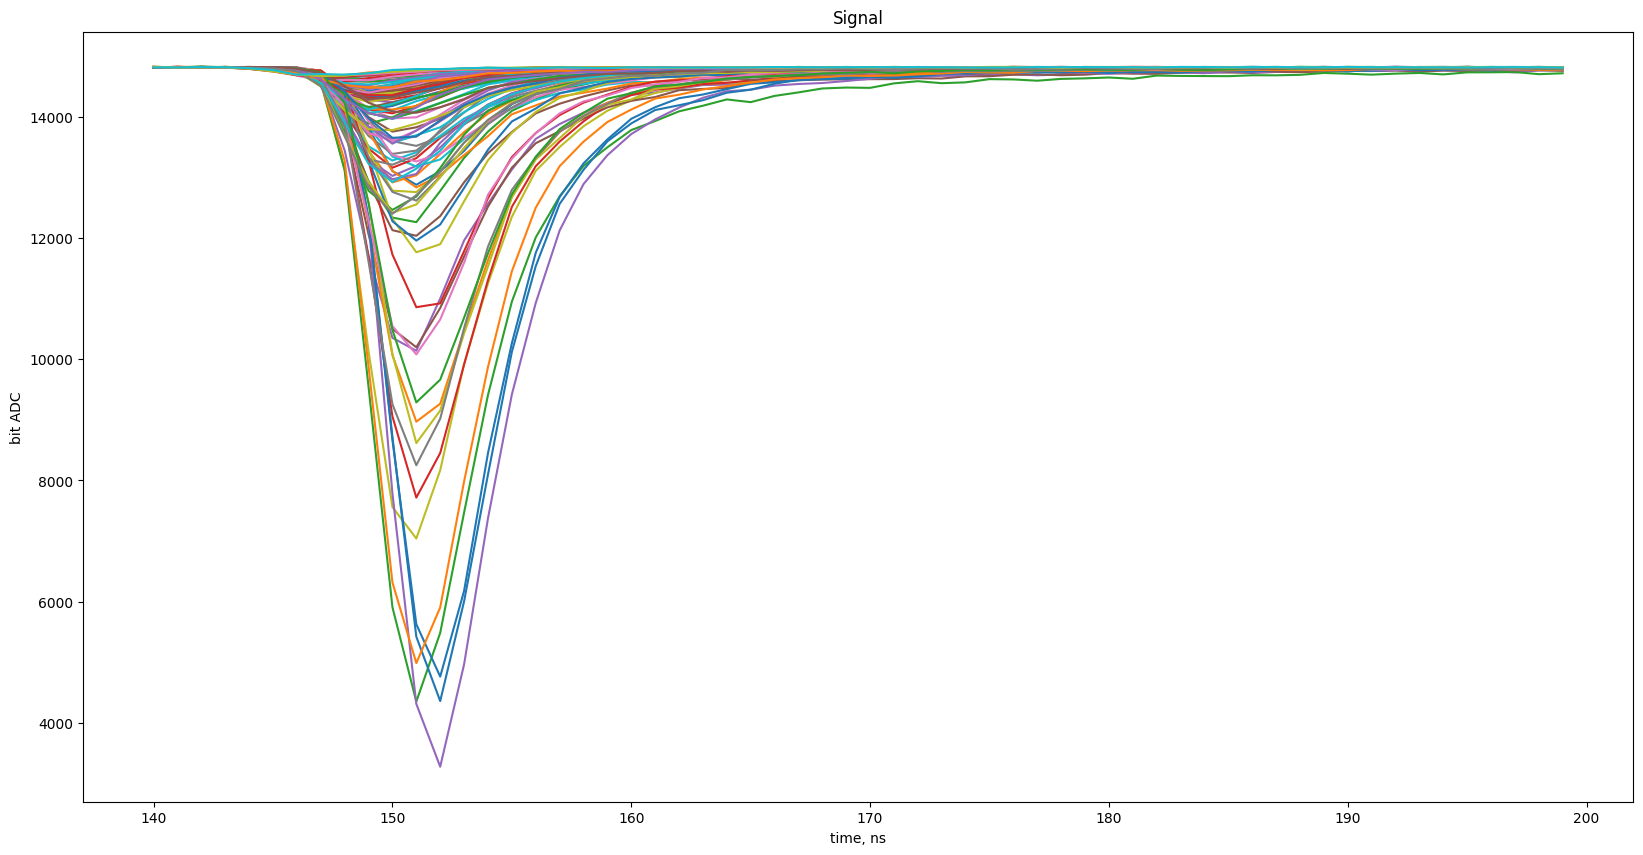

In [104]:
#прекод из Каггла

N=range(0,100)
ax = X.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

###Скажу честно, мне очень понравился этот график. Мы берем первые 100 строк из нашего датасета, транспонируем таблицу и делаем срез по времени. Как я понимаю [140:200] - именно в этом временном промежутко происходит появление - пик - затухание сигнала.

###Это является первым шагом к пониманию того, как мы будем всё кластеризировать. Пока не отказываемся от идеи K-Means и Isolation Forest.

#Предобработка данных и понижение размерности

In [105]:
#посмотрим количество пропусков
print(X.isna().sum().sum())

0


###Невероятные 0 пропусков.

In [106]:
#вторым, что сделаем - масшабируем признаки, тк K-Means крайне чувствителен к масштабу признаков
#из обучающих материалов с платформы:
#"Чувствительность к выбросам – одиночные выбросы могут сильно сместить центроиды и ухудшить результаты кластеризации."

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [107]:
#применяем PCA (доля объясненной дисперсии 90% + не забываем про воспроизводимость)
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Число главных компонент = {X_pca.shape[1]}')

Число главных компонент = 311


###Из 500 признаков выделилось 311 главных компонент. Из этого можно сделать примерные выводы. Данные очень разнообразны. Импульсы содержат много уникальных деталей. Учитывая то, что K-Means плохо работает с кластерами сложной формы, делаем волевое решение не использовать эту модель.

###Вместо этого мы используем UMAP, чтобы побороться с проклятием размерности, которое так мешает DBSCAN, и используем модель.

###На этом этапе произошел некий "поворотный" момент, так как я отказался от своего любимого и простого K-Means в пользу DBSCAN. Не очень сильно расстроен, так как в ДЗ №3 мне не довелось попробовать эту модель, но довелось использовать K-Means.

###Что стоит упомянуть: X_umap мы будем использовать только для DBSCAN. Isolation Forest мы будем использовать на исходных масштабированных данных (X_scaled), чтобы получить все выбросы. DBSCAN же мы используем уже на X_umap.

###Поэтому план следующий:
###1. Обучаем Isolation Forest
###2. Берем от него НЕ выбросы
###3. Применяем UMAP к данным из пункта 2
###4. Применяем DBSCAN к данным из пункта 3
###5. Собираем всё (аномалии Isolation Forest - первый кластер + два кластера от DBSCAN), что получилось и формируем для сабмита

#Обучение DBSCAN и Isolation Forest

In [108]:

#Сначала обучим Isolation Forest
#гиперпараметры возьмем дефолтные (из обучающих материалов)
#n_estimators = 100
#contamination = 0.05 (тут поменял, было 0.01, что, как мне кажется, слишком мало)

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=RANDOM_STATE)
anomalies = iso_forest.fit_predict(X_scaled)

In [109]:
#теперь сделаем следующее - создадим маску для нормальных сигналов, учитывая результат Isolation Forest.
#то есть выделим то, где anomalies == 1
#после этого (можно сказать, на чистых данных) применим UMAP и обучим

not_anomaly_values_mask = (anomalies == 1)
X_scaled_normal = X_scaled[not_anomaly_values_mask]

In [110]:
#применяем UMAP
#для umap выберем следующие параметры (все пояснения даны на основе обучающего материала с платформы):
#n_neighbors = 15 - для сохранения глобальной геометрии
#min_dist = 0.1 - для контроля плотности кластеров. Значение 0.1 позволит точкам плотно группироваться
#n_components = 2 - для 2д отображения (для визуального анализа в будущем)

umap_reduce = umap.UMAP(n_neighbors=15, min_dist = 0.1, n_components = 2, random_state=RANDOM_STATE)
X_umap_normal = umap_reduce.fit_transform(X_scaled_normal)

#на всякий случай, переведем все в float64 (иначе предупреждения от DBSCAN вылетают)
X_umap_normal = X_umap_normal.astype(np.float64)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [111]:
#запускаем DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=15)
db_labels = dbscan.fit_predict(X_umap_normal)

#Сбор кластеров в единый файл

In [112]:
#инициализируем итоговый массив меток и переносим результаты DBSCAN
#предзаполним его двойками, так как далее Кластер 2 будем использовать для обозначения аномалий или шума
final_labels = np.full(len(X), 2)


#теперь получим глобальные индексы строк, которы Isolation Forest посчитал нормальными
global_normal_id = np.where(not_anomaly_values_mask)[0]

#создаем ещё одну маску для элементов, которые DBSCAN не посчитал шумом (то есть они == 0 или == 1)
db_labels_clean = (db_labels != -1)

#оставляем только те глобальные индексы, которые одобрили обе модели
final_clean_id = global_normal_id[db_labels_clean]

#переносим чистые метки от DBSCAN (0 и 1) в их глобальные позиции
final_labels[final_clean_id] = db_labels[db_labels_clean]

In [113]:
#все сигналы, которые Isolation Forest признал аномалиями (-1), а так же те, что DBSCAN посчитал шумом (так же -1),
#отправляем в Кластер 2
final_labels[anomalies == -1] = 2
final_labels[global_normal_id[db_labels == -1]] = 2

In [114]:
#оформляем файл для Каггла
submission = pd.DataFrame({'index': range(len(final_labels)), 'cluster': final_labels.astype(int)})

#строка закоменчена, чтобы не создавать дополнительный файл
#далее применяется модель, которая чуток улучшила его
#submission.to_csv('not final submission.csv', index=False)

#И получаем ужасный скор
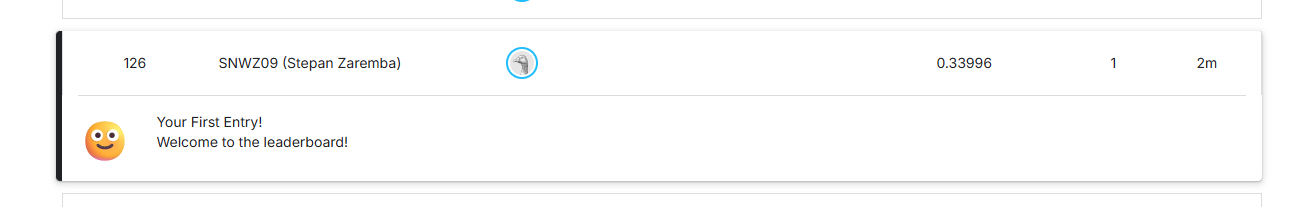

#Чтобы хотя бы немного улучшить скор, попробуем использовать модель, которую подсказала нейросеть
#Этой моделью будет GMM (Gaussian Mixture Model). Эта модель при кластеризации руководствуется теорией вероятностей. Если K-Means проводит границу между кластерами, то GMM рассчитывает вероятность для каждой точки (например, эта точка на 63% похожа на кластер 1 и на 37 на кластер 2).

#Так же, мы используем физический подбор признаков. Выберем пиковое значение, площадь под графиков, площадь хвоста (например, точки после 180) и отношение хвоста к полной площади

#Модель GMM

In [121]:
#прочитаем заново файл
X = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
X = X.drop([0, 1, 2, 3, 504], axis=1)
X.columns = list(range(500))
X.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [122]:
#пишем признаки
X_features = pd.DataFrame()

#пиковое значение
X_features['peak'] = X.max(axis=1)

#площадь под графиком
X_features['total_area'] = X.sum(axis=1)

#площадь хвоста
# Хвост — это ключевой параметр, разделяющий нейтроны и гамма-кванты
X_features['tail_area'] = X.iloc[:, 180:].sum(axis=1)

#отношение хвоста к полной площади
#1e-6 для защиты от ошибки, если площадь будет ровно 0
X_features['psd_ratio'] = X_features['tail_area'] / (X_features['total_area'] + 1e-6)

#и теперь масштабируем наши новые 4 признаки
scaler = StandardScaler()
X_scaled_features = scaler.fit_transform(X_features)

In [133]:
#применяем Isolation Forest на масштабированных признаках
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=RANDOM_STATE)
anomalies = iso_forest.fit_predict(X_scaled_features)

#и опять формируем маску
final_labels = np.zeros(len(X))
normal_mask = (anomalies == 1)

In [134]:
#обучаем модель GMM с учетом нашего RANDOM_STATE и только что созданной маски
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels_normal = gmm.fit_predict(X_scaled_features[normal_mask])

In [135]:
#переносим в массив
final_labels[normal_mask] = gmm_labels_normal

In [136]:
#теперь собираем весь шум и аномалии и создаем итоговый файл
final_labels[anomalies == -1] = 2

submission = pd.DataFrame({
    'index': range(len(final_labels)),
    'cluster': final_labels.astype(int)
})

In [83]:
#посмотрим распределение кластеров
print(submission['cluster'].value_counts())

cluster
1    15148
0     7157
2     1174
Name: count, dtype: int64


In [84]:
submission.to_csv('final submission.csv', index=False)

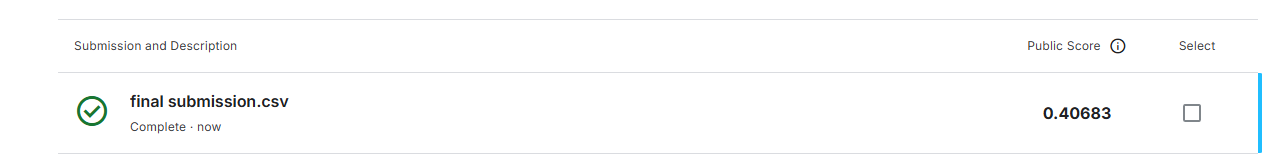

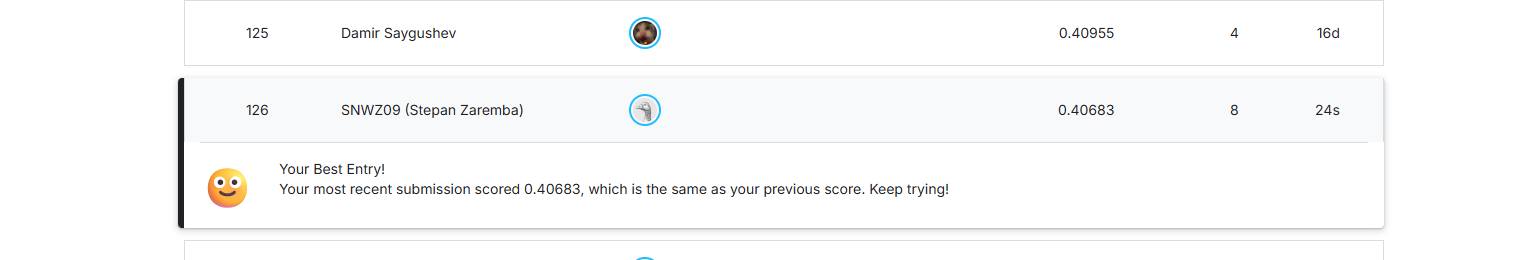

###Таким образом, применив новую модель скор получилось улучшить на ~ 0.07

#Попробуем перебрать гиперпараметры

###Немного посмотрев информацию в интернете сделал вывод, что лучше в качестве ориентира выбрать Байесовский информационный критерий (BIC), а не силуэт, так как последний ожидает кластеры в виде плотных сфер (то есть GMM вообще мимо с её сильновытягивающимися кластерами).

In [140]:
#n_components тоже покручу немного
#я понимаю, что, учитывая задание, количество кластеров фиксировано
#это просто мой интерес
n_components_values = [2, 3, 4, 5]
covariance_types = ['full', 'tied', 'diag', 'spherical']

In [141]:
#сюда будем записывать все результаты

gmm_results = []
best_bic = np.inf
best_gmm_params = {}

In [142]:
for n_comp in n_components_values:
    for cov_type in covariance_types:
        gmm = GaussianMixture(n_components=n_comp, covariance_type=cov_type, random_state=RANDOM_STATE)
        gmm.fit(X_scaled_features)

        #считаем БИК
        bic = gmm.bic(X_scaled_features)
        labels = gmm.predict(X_scaled_features)

        #считаем силуэт (потому что я не верю информации в интернете)
        score = silhouette_score(X_scaled_features, labels)

        gmm_results.append({
            'n_components': n_comp,
            'covariance_type': cov_type,
            'BIC': bic,
            'AIC': aic,
            'silhouette': score
        })

        #чем меньше БИК, тем лучше
        if bic < best_bic:
            best_bic = bic
            best_gmm_params = {'n_components': n_comp, 'covariance_type': cov_type}

In [143]:
#после 3-ух минут ожидания смотрим результаты
X_gmm_results = pd.DataFrame(gmm_results)
print('Лучшие параметры по БИК:', best_gmm_params)

Лучшие параметры по БИК: {'n_components': 5, 'covariance_type': 'full'}


In [144]:
#и отсортируем по БИК, чтобы посмотреть, какие вообще варианты были
display(df_gmm_results.sort_values(by='BIC', ascending=True).head())

,n_components,covariance_type,BIC,AIC,silhouette
12,5,full,-152046.667203,-152643.392968,0.116613
8,4,full,-140648.879956,-141124.647795,0.201301
4,3,full,-134443.080042,-134797.889956,0.284551
0,2,full,-114448.816637,-114682.668625,0.472750
13,5,tied,-78466.029988,-78740.201285,0.332410


###Наше дефолтное значение оказалось в топе на четвертом месте.
###Естественно, это уже неправильно, так как компонентов 5, а нужно 2.

In [137]:
#применяем Isolation Forest на масштабированных признаках
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=RANDOM_STATE)
anomalies = iso_forest.fit_predict(X_scaled_features)

#и опять формируем маску
final_labels = np.zeros(len(X))
normal_mask = (anomalies == 1)

#обучаем модель GMM с учетом нашего RANDOM_STATE и только что созданной маски
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels_normal = gmm.fit_predict(X_scaled_features[normal_mask])

#переносим в массив
final_labels[normal_mask] = gmm_labels_normal

#теперь собираем весь шум и аномалии и создаем итоговый файл
final_labels[anomalies == -1] = 2

submission = pd.DataFrame({
    'index': range(len(final_labels)),
    'cluster': final_labels.astype(int)
})

#submission.to_csv('final final submission.csv', index=False)

#Скор, естественно, упал

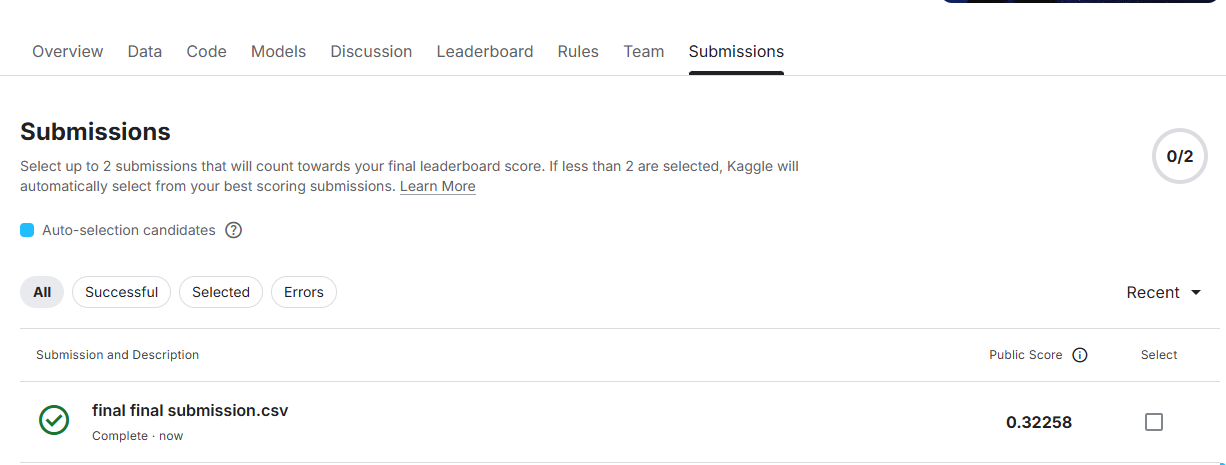


In [149]:
#так как интернет опять обманул, отсортируем все-таки по силуэту и поставим n_components=2
#может, там есть какие-то значения повыше
display(df_gmm_results.sort_values(by='silhouette', ascending=False).head())

,n_components,covariance_type,BIC,AIC,silhouette
1,2,tied,-54278.564062,-54431.777434,0.616532
3,2,spherical,211715.572201,211626.869722,0.491981
0,2,full,-114448.816637,-114682.668625,0.472750
5,3,tied,-65772.849113,-65966.381794,0.466326
2,2,diag,156821.864012,156684.778363,0.353194


###Попробуем поставить covariance_type на tied и залить на Каггл

In [148]:
#применяем Isolation Forest на масштабированных признаках
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=RANDOM_STATE)
anomalies = iso_forest.fit_predict(X_scaled_features)

#и опять формируем маску
final_labels = np.zeros(len(X))
normal_mask = (anomalies == 1)

#обучаем модель GMM с учетом нашего RANDOM_STATE и только что созданной маски
gmm = GaussianMixture(n_components=2, covariance_type='tied', random_state=RANDOM_STATE)
gmm_labels_normal = gmm.fit_predict(X_scaled_features[normal_mask])

#переносим в массив
final_labels[normal_mask] = gmm_labels_normal

#теперь собираем весь шум и аномалии и создаем итоговый файл
final_labels[anomalies == -1] = 2

submission = pd.DataFrame({
    'index': range(len(final_labels)),
    'cluster': final_labels.astype(int)
})

#submission.to_csv('final final final submission.csv', index=False)

##К сожалению, после подбора гиперпараметров и двух сабмитов скор так и не повысился.
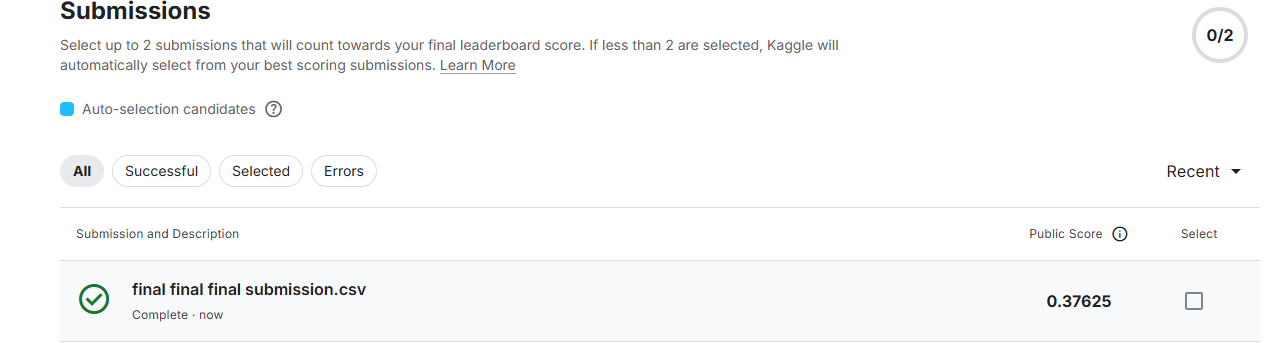

#Итоговый скор = 0.40683
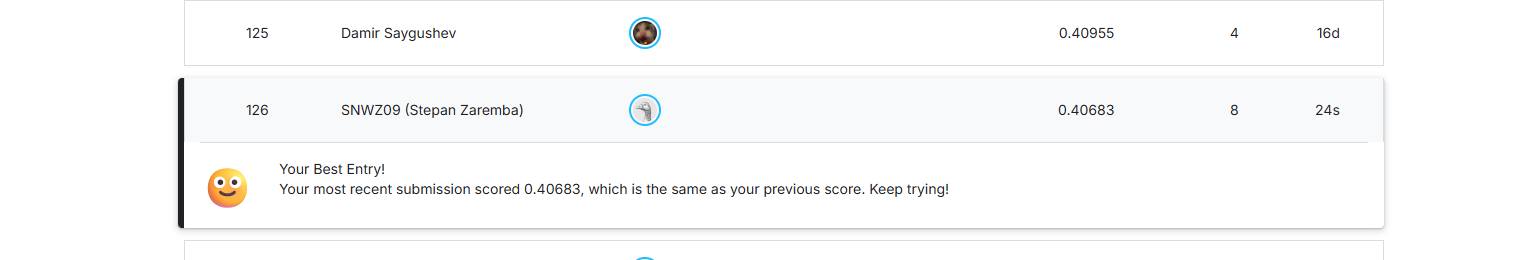

#К сожалению, скор все равно получился маленький. Тем не менее, я не считаю, что это повод расстраиваться. Да, все мои модели и файлы очень далеки от идеала, и только моя вина в том, что я их не могу улучшить. Тем не менее, всё не так печально.

#Если резюмировать всю работу - мне очень понравилось. Я был очень рад, что моя идея UMAP + DBSCAN + Isolation Forest оказалась в принципе рабочей.

#В ходе данной работы были использованы две комбинации: UMAP + DBSCAN + Isolation Forest и Физический подбор признаков + GMM + Isolation Forest.
#Первая "архитектура" показала более низкую эффективность в задаче раздления частиц по сравнению со второй.
#Вторая "архитектура" стала возможной только при создании новых признаков:
#1. Пиковое значение - максимальная амплитуда сигнала;
#2. Площадь под графиком - сумма всех 500 значений;
#3. Площадь хвоста - сумма значений сигнала со 180-ой точки и до конца;
#4. Отношение хвоста к полной площади - чтобы показать, какая доля от сигнала ушла в хвост.

#Подбор гиперпараметров не увенчался успехом, но позволил более четко изучить модель GMM.

#Таким образом, сигналы были кластеризированы.